## Minimal Radar Chart (Matplotlib – Correct Way)
🔹 Key idea

Convert features to polar coordinates

Close the polygon (first value repeated)

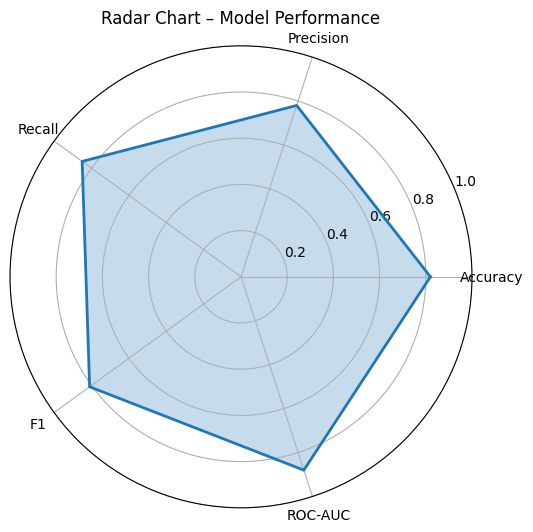

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Features and values
labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
values = [0.82, 0.78, 0.85, 0.81, 0.88]

# Number of variables
N = len(labels)

# Angles
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Close values
values += values[:1]

# Plot
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.25)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)
ax.set_title("Radar Chart – Model Performance")

plt.show()


## Radar Chart with Standardization (Real Data)
🔹 Radar plots require normalization

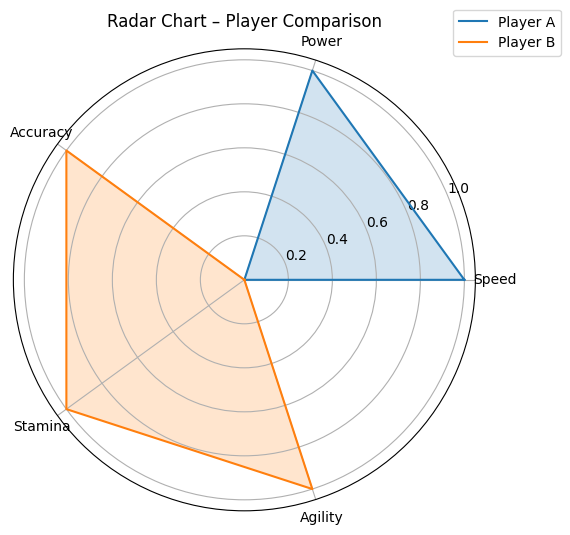

In [2]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Multivariate data
df = pd.DataFrame({
    "Speed": [80, 70],
    "Power": [90, 85],
    "Accuracy": [75, 88],
    "Stamina": [85, 90],
    "Agility": [78, 82]
}, index=["Player A", "Player B"])

# Scale to [0, 1]
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(scaled, columns=df.columns, index=df.index)

labels = df_scaled.columns.tolist()
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for idx in df_scaled.index:
    values = df_scaled.loc[idx].tolist()
    values += values[:1]
    ax.plot(angles, values, label=idx)
    ax.fill(angles, values, alpha=0.2)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_title("Radar Chart – Player Comparison")
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

plt.show()


## Radar Chart for ML Model Comparison (Very Common)

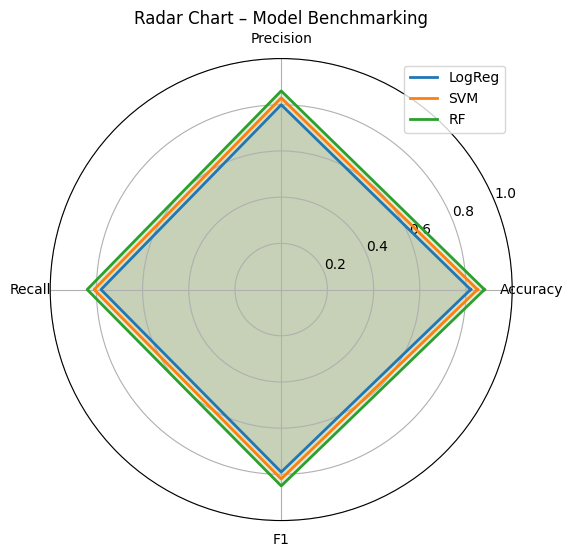

In [3]:
models = ["LogReg", "SVM", "RF"]
metrics = ["Accuracy", "Precision", "Recall", "F1"]

scores = np.array([
    [0.82, 0.80, 0.78, 0.79],
    [0.85, 0.83, 0.81, 0.82],
    [0.88, 0.86, 0.84, 0.85],
])

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for model, score in zip(models, scores):
    vals = score.tolist() + score[:1].tolist()
    ax.plot(angles, vals, linewidth=2, label=model)
    ax.fill(angles, vals, alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
ax.set_ylim(0, 1)
ax.set_title("Radar Chart – Model Benchmarking")
ax.legend()

plt.show()


## Radar Chart with Error Bands (Advanced)

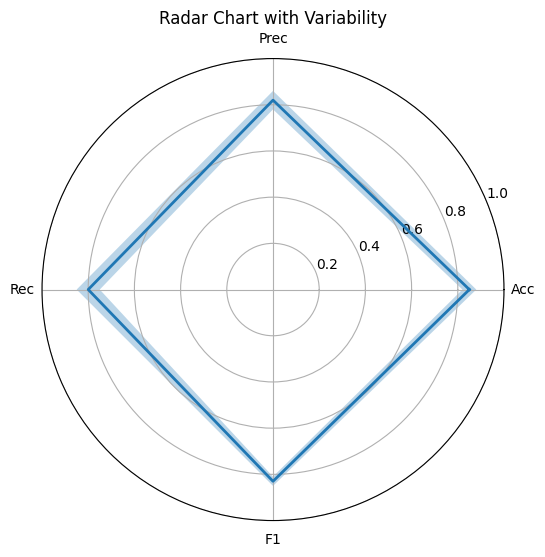

In [4]:
mean = np.array([0.85, 0.82, 0.80, 0.83])
std = np.array([0.03, 0.04, 0.05, 0.02])

angles = np.linspace(0, 2 * np.pi, len(mean), endpoint=False)
angles = np.concatenate([angles, angles[:1]])

mean = np.concatenate([mean, mean[:1]])
std = np.concatenate([std, std[:1]])

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, mean, linewidth=2)
ax.fill_between(angles, mean - std, mean + std, alpha=0.3)

ax.set_thetagrids(np.degrees(angles[:-1]), ["Acc", "Prec", "Rec", "F1"])
ax.set_title("Radar Chart with Variability")
ax.set_ylim(0, 1)

plt.show()


## Interactive Radar Chart (Plotly)

In [5]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=[0.82, 0.78, 0.85, 0.81, 0.88],
    theta=["Acc", "Prec", "Rec", "F1", "ROC"],
    fill="toself",
    name="Model A"
))

fig.add_trace(go.Scatterpolar(
    r=[0.88, 0.85, 0.87, 0.86, 0.90],
    theta=["Acc", "Prec", "Rec", "F1", "ROC"],
    fill="toself",
    name="Model B"
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title="Interactive Radar Chart"
)

fig.show()
